In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('/home/hgf_hmgu/hgf_gib4562/tdmpc2')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from analysis.utils import reconstruct_cartpole_dmcontrol

In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2')
from tdmpc2 import TDMPC2
from tqdm import tqdm
from envs import make_env
from hydra import initialize, compose
from omegaconf import OmegaConf
from common.parser import parse_cfg
from common.seed import set_seed
# from common.trajectory_controller import TrajectoryController
# from common.activation_patcher import ActivationPatcher

from analysis.utils import load_sweep_metadata, load_data

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied



In [5]:
df_metadata = load_sweep_metadata(
    ["logs/25-12-09-cartpole_initial_conditions_seeds_models"],
    json_file_name="episode_metadata.json")
df_metadata = df_metadata[df_metadata['checkpoint'] ==
                          'ckpts/cartpole-swingup-3.pt']
df = load_data(df_metadata,
               cart_position=[0],
               episode_file_name="episode_data.pkl")

Dirs in logs/25-12-09-cartpole_initial_conditions_seeds_models: 100%|██████████| 825/825 [00:00<00:00, 12566.78it/s]


Found 825 configurations
Found 55 configurations


100%|██████████| 55/55 [00:00<00:00, 200.74it/s]


In [83]:
z = np.concatenate(df['latent_states'].tolist())
actions = np.concatenate(df['actions'].tolist())
observations = np.concatenate(df['observations'].tolist())
rewards = np.concatenate(df['rewards'].tolist())

z = torch.from_numpy(z).to('cuda')
observations = torch.from_numpy(observations).to('cuda')
actions = torch.from_numpy(actions).to('cuda')
observations.shape, actions.shape, z.shape, rewards.shape

(torch.Size([27500, 5]),
 torch.Size([27500, 1]),
 torch.Size([27500, 512]),
 (27500,))

## Fit a linear decoder from z to x

Linear Decoder (z -> obs) Fit:
  MSE: 0.000163
  Mean R²: 0.999789
  R² per dimension: [0.99985182 0.9999305  0.99973309 0.99957085 0.99985939]


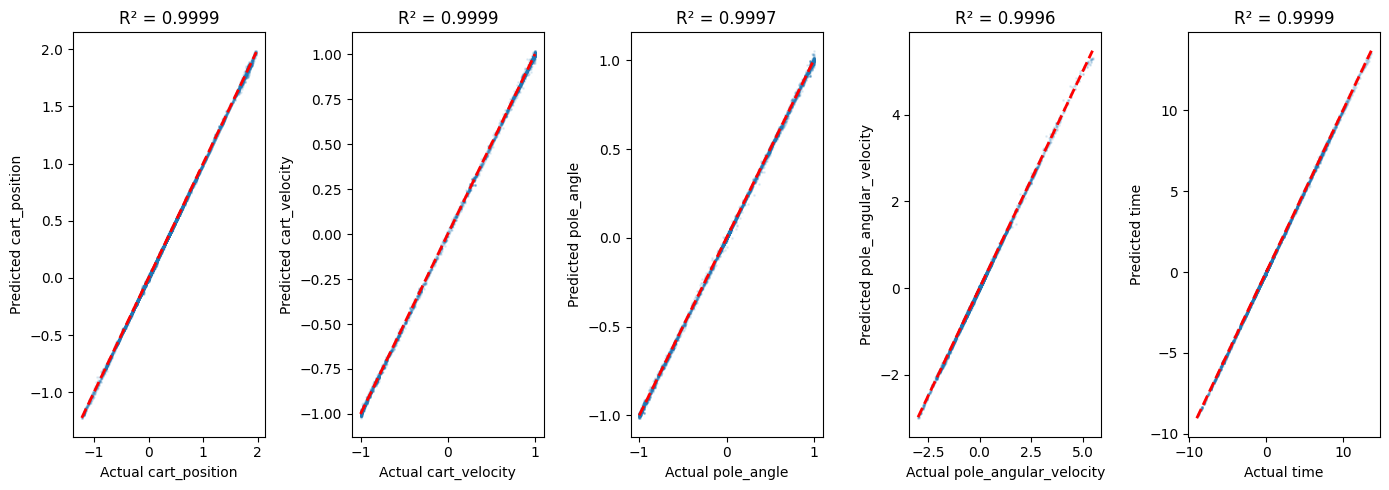

In [97]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Fit linear decoder: obs = W*z + b using sklearn
z_np = z.cpu().numpy()
obs_np = observations.cpu().numpy()

# Fit the model
decoder = LinearRegression()
decoder.fit(z_np, obs_np)

# Compute predictions
obs_pred = decoder.predict(z_np)

# Compute R² for each observation dimension
r2_per_dim = []
for i in range(obs_np.shape[1]):
    r2 = r2_score(obs_np[:, i], obs_pred[:, i])
    r2_per_dim.append(r2)
r2_per_dim = np.array(r2_per_dim)

# Compute overall metrics
mse = mean_squared_error(obs_np, obs_pred)
mean_r2 = np.mean(r2_per_dim)

print(f"Linear Decoder (z -> obs) Fit:")
print(f"  MSE: {mse:.6f}")
print(f"  Mean R²: {mean_r2:.6f}")
print(f"  R² per dimension: {r2_per_dim}")

# Visualize predictions vs actual
fig, axes = plt.subplots(1, obs_np.shape[1], figsize=(14, 5))
obs_names = [
    'cart_position', 'cart_velocity', 'pole_angle', 'pole_angular_velocity',
    'time'
]
for i in range(obs_np.shape[1]):
    axes[i].scatter(obs_np[:, i], obs_pred[:, i], alpha=0.1, s=1)
    axes[i].plot([obs_np[:, i].min(), obs_np[:, i].max()],
                 [obs_np[:, i].min(), obs_np[:, i].max()],
                 'r--',
                 lw=2)
    axes[i].set_xlabel(f'Actual {obs_names[i]}')
    axes[i].set_ylabel(f'Predicted {obs_names[i]}')
    axes[i].set_title(f'R² = {r2_per_dim[i]:.4f}')
plt.tight_layout()
plt.show()


In [7]:
# # Fit linear dynamics model: z_{t+1} = A*z_t + B*a_t
# # Prepare data: we need z_t, a_t, and z_{t+1}
# z_t = z[:-1]  # Current states
# a_t = actions[:-1]  # Actions taken
# z_next = z[1:]  # Next states

# # Convert to numpy for linear regression
# z_t_np = z_t.cpu().numpy()
# a_t_np = a_t.cpu().numpy()
# z_next_np = z_next.cpu().numpy()

# # Concatenate z_t and a_t to form the input matrix X
# X = np.concatenate([z_t_np, a_t_np], axis=1)  # Shape: (N, 512+1)

# # Solve for [A, B] using least squares: z_{t+1} = [A, B] @ [z_t; a_t]
# # X @ W = z_next, where W = [A; B]
# W = np.linalg.lstsq(X, z_next_np, rcond=None)[0]  # Shape: (513, 512)

# # Split W back into A and B
# A = W[:512, :]  # Shape: (512, 512)
# B = W[512:, :]  # Shape: (1, 512)

# # Compute predictions
# z_pred = X @ W  # Shape: (N, 512)

# # Compute goodness of fit metrics
# mse = np.mean((z_next_np - z_pred)**2)
# r2_per_dim = []
# for i in range(z_next_np.shape[1]):
#     ss_res = np.sum((z_next_np[:, i] - z_pred[:, i])**2)
#     ss_tot = np.sum((z_next_np[:, i] - np.mean(z_next_np[:, i]))**2)
#     r2 = 1 - (ss_res / ss_tot)
#     r2_per_dim.append(r2)
# r2_per_dim = np.array(r2_per_dim)
# mean_r2 = np.mean(r2_per_dim)

# print(f"Linear Dynamics Model Fit:")
# print(f"  MSE: {mse:.6f}")
# print(f"  Mean R²: {mean_r2:.6f}")
# print(f"  R² range: [{np.min(r2_per_dim):.6f}, {np.max(r2_per_dim):.6f}]")

# # Visualize goodness of fit
# fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# # Plot 1: R² distribution across latent dimensions
# axes[0, 0].hist(r2_per_dim, bins=50, edgecolor='black')
# axes[0, 0].set_xlabel('R² Score')
# axes[0, 0].set_ylabel('Frequency')
# axes[0, 0].set_title(f'R² Distribution (Mean: {mean_r2:.4f})')
# axes[0, 0].axvline(mean_r2,
#                    color='red',
#                    linestyle='--',
#                    label=f'Mean: {mean_r2:.4f}')
# axes[0, 0].legend()

# # Plot 2: Predicted vs Actual for a few random dimensions
# sample_dims = np.random.choice(z_next_np.shape[1], size=3, replace=False)
# for dim in sample_dims:
#     axes[0, 1].scatter(z_next_np[:, dim],
#                        z_pred[:, dim],
#                        alpha=0.3,
#                        s=1,
#                        label=f'Dim {dim}')
# axes[0, 1].plot([z_next_np.min(), z_next_np.max()],
#                 [z_next_np.min(), z_next_np.max()],
#                 'r--',
#                 label='Perfect fit')
# axes[0, 1].set_xlabel('Actual z_{t+1}')
# axes[0, 1].set_ylabel('Predicted z_{t+1}')
# axes[0, 1].set_title('Predicted vs Actual (Sample Dimensions)')
# axes[0, 1].legend()

# # Plot 3: Prediction error over time
# prediction_error = np.linalg.norm(z_next_np - z_pred, axis=1)
# axes[1, 0].plot(prediction_error, alpha=0.7)
# axes[1, 0].set_xlabel('Time Step')
# axes[1, 0].set_ylabel('Prediction Error (L2 norm)')
# axes[1, 0].set_title('Prediction Error Over Time')

# # Plot 4: R² per dimension (sorted)
# sorted_r2 = np.sort(r2_per_dim)
# axes[1, 1].plot(sorted_r2)
# axes[1, 1].set_xlabel('Latent Dimension (sorted)')
# axes[1, 1].set_ylabel('R² Score')
# axes[1, 1].set_title('R² Score per Latent Dimension (Sorted)')
# axes[1, 1].axhline(mean_r2,
#                    color='red',
#                    linestyle='--',
#                    label=f'Mean: {mean_r2:.4f}')
# axes[1, 1].legend()

# plt.tight_layout()
# plt.show()

# # Print matrix norms for A and B
# print(f"\nMatrix properties:")
# print(f"  ||A||_F: {np.linalg.norm(A, 'fro'):.4f}")
# print(f"  ||B||_F: {np.linalg.norm(B, 'fro'):.4f}")
# print(f"  A shape: {A.shape}")
# print(f"  B shape: {B.shape}")


In [8]:
#plt.plot(prediction_error[idx_start:idx_end - 1])

In [10]:
# Base configuration
CKPT_PATH = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpole-swingup-3.pt'
override_cfg = dict(
    task='cartpole-swingup',
    checkpoint=CKPT_PATH,
    obs='state',
    seed=0,
    compile=False,
    mpc=True,
    multitask=False,
    model_size=5,
    save_video=False,  # Disable video to speed up sweep
    record_planning=False,  # Focus on episode data
)

with initialize(config_path="tdmpc2", version_base=None):
    cfg = compose(config_name="config")
    OmegaConf.set_struct(cfg, False)
    cfg = OmegaConf.merge(cfg, override_cfg)

# Parse config
cfg = parse_cfg(cfg)
set_seed(cfg.seed)

cfg.initial_state = {
    'qpos': {
        'slider': 0,  #cart position
        'hinge_1': 0,  # pole angle
    },
}

env = make_env(cfg)

print("\nLoading agent...")
agent = TDMPC2(cfg)

# Optionally load checkpoint
if hasattr(cfg, 'checkpoint') and cfg.checkpoint:
    print(f"Loading checkpoint: {cfg.checkpoint}")
    agent.load(cfg.checkpoint)


Loading agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: /home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpole-swingup-3.pt


## Analysi sof prediciton errors

In [12]:
mask_stable = observations[:, 1] > 0.99
mask_unstable = ~mask_stable
mask_stable = mask_stable.detach().cpu().numpy()
mask_unstable = mask_unstable.detach().cpu().numpy()

z_stable = z[mask_stable]
actions_stable = actions[mask_stable]
observations_stable = observations[mask_stable]

z_swingup = z[mask_unstable]
actions_swingup = actions[mask_unstable]
observations_swingup = observations[mask_unstable]

len(z_stable), len(z_swingup)

(22932, 4568)

In [110]:
# Function to compute multi-step prediction errors
def compute_multistep_prediction_errors(agent,
                                        z,
                                        actions,
                                        observations,
                                        k=1,
                                        open_loop=True,
                                        randomize_actions=False,
                                        use_linear_model=False,
                                        use_zero_dynamics=False,
                                        A=None,
                                        B=None,
                                        add_physical_error=False,
                                        decoder=None):
    """
    Compute k-step prediction errors.
    
    Args:
        agent: The TDMPC2 agent with the world model
        z: Latent states [T, latent_dim]
        actions: Actions [T, action_dim]
        observations: Observations [T, obs_dim]
        k: Number of steps to predict ahead
        open_loop: If True, use closed-loop rollout (predict from previous prediction).
                   If False, re-encode true observation at each step.
        randomize_actions: If True, use random actions instead of the provided actions (baseline).
        use_zero_dynamics: If True, use zero dynamics baseline where z_t+1 = z_t.
    
    Returns:
        prediction_errors: Array of prediction errors [T-k, k] - one error per step
        z_preds: Array of predicted latent states
    """
    prediction_latent_errors = []
    prediction_physical_errors = []
    z_preds = []
    for t in tqdm(range(len(z) - k)):
        # Start from z[t] and rollout k steps
        z_pred = z[t]
        z_preds.append(z_pred.detach().cpu().numpy())

        step_latent_errors = []
        step_physical_errors = []
        for step in range(k):
            # Use random actions if randomize_actions is True
            action = actions[t + step]
            if randomize_actions:
                action = torch.rand_like(
                    actions[t + step]) * 2 - 1  # Random actions in [-1, 1]

            if use_zero_dynamics:
                # Zero dynamics baseline: z_t+1 = z_t (no change)
                pass  # z_pred stays the same
            # elif use_linear_model:
            #     z_pred = z_pred.unsqueeze(0) @ A + action.unsqueeze(0) @ B
            #     z_pred = z_pred.squeeze(0)
            else:
                with torch.no_grad():
                    z_pred = agent.model.next(z_pred, action, task=None)
                    z_preds.append(z_pred.cpu().numpy())

            # Compare with actual latent state at t+step+1
            # z_target = agent.model.encode(observations[t + step + 1], task=None)
            # z_pred: d(z_{t+k}), z_target: z_{t+k+1}
            z_target = z[t + step + 1]

            # |z_{t+k} - z_{t+k+1}|
            error_latent = (z_pred - z_target).pow(2).sum(-1)

            if add_physical_error:
                assert decoder is not None, "Decoder is required for physical error"
                # |decod(z_{t+k}) - decod(z_{t+k+1})|
                error_physical = np.sum(np.power(
                    decoder.predict(z_pred.cpu().numpy().reshape(1, -1)) -
                    decoder.predict(z_target.cpu().numpy().reshape(1, -1)), 2),
                                        axis=-1)
                step_physical_errors.append(error_physical)
            # if add_physical_error:
            #     # |x_{t+k+1} - x_{t+k}|
            #     error_physical_true = (observations[t + step + 1] -
            #                            observations[t + step])

            #     # |decod(d(z_t+k)) - decod(z_t)|
            #     x_tk = decoder(z_pred)
            #     x_t = decoder(z[t])
            #     error_physical_pred = (x_tk - x_t).pow(2).sum(-1)

            step_latent_errors.append(error_latent.item())

            # If not open loop, re-encode the true observation for next prediction
            if open_loop:
                z_pred = z_target  #this is the same as z[t+step+1]

        prediction_latent_errors.append(step_latent_errors)
        prediction_physical_errors.append(step_physical_errors)

    return np.array(prediction_latent_errors), np.array(
        prediction_physical_errors), np.array(z_preds)


In [14]:
# # Compute prediction errors for k=3 steps ahead
# k = 5
# prediction_errors = compute_multistep_prediction_errors(
#     agent,
#     z,
#     actions,
#     observations,
#     use_linear_model=True,
#     k=k,
#     A=torch.from_numpy(A).to(z.device),
#     B=torch.from_numpy(B).to(z.device))


In [ ]:
# predictions_errors_stable = prediction_errors[mask_stable[:-k]]
# predictions_errors_swingup = prediction_errors[mask_unstable[:-k]]

# len(predictions_errors_stable), len(predictions_errors_swingup)


(22929, 4568)

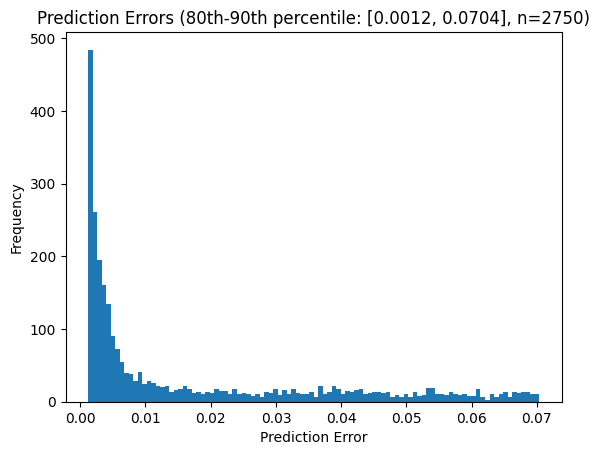

In [ ]:
# # Filter out first X percentile and last X percentile
# lower_percentile = 80  # Remove bottom 10%
# upper_percentile = 90  # Remove top 10%

# lower_bound = np.percentile(prediction_errors, lower_percentile)
# upper_bound = np.percentile(prediction_errors, upper_percentile)
# filtered_errors = prediction_errors[(prediction_errors >= lower_bound) &
#                                     (prediction_errors <= upper_bound)]

# plt.hist(filtered_errors, bins=100)
# plt.xlabel('Prediction Error')
# plt.ylabel('Frequency')
# plt.title(
#     f'Prediction Errors ({lower_percentile}th-{upper_percentile}th percentile: [{lower_bound:.4f}, {upper_bound:.4f}], n={len(filtered_errors)})'
# )
# plt.show()

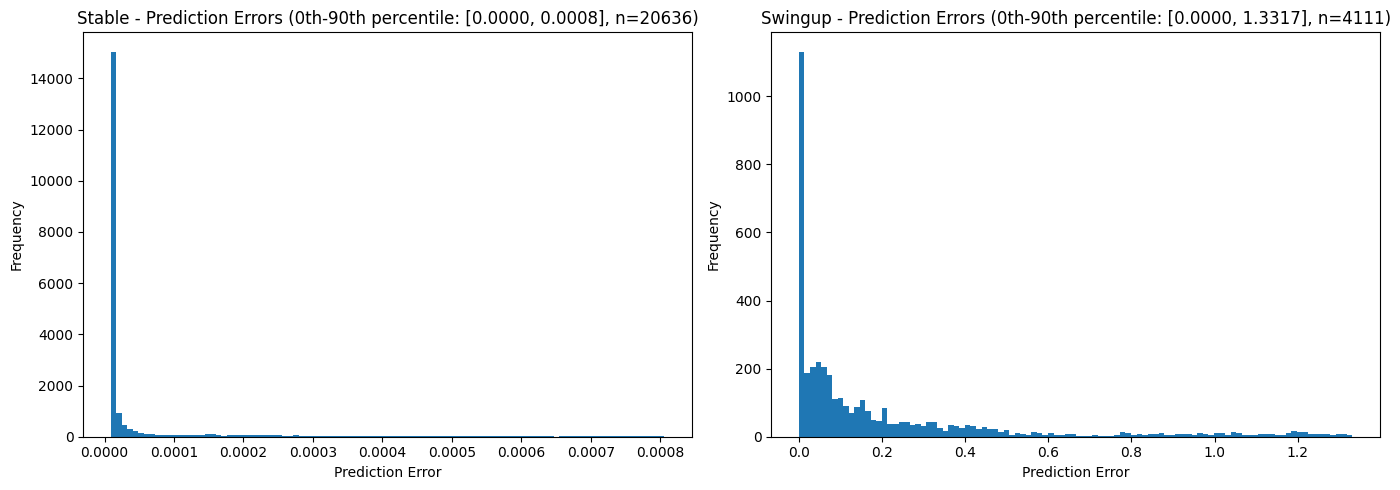

In [118]:
# Filter out first X percentile and last X percentile
lower_percentile = 0  # Remove bottom 10%
upper_percentile = 90  # Remove top 10%

# Create side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Stable errors
lower_bound_stable = np.percentile(predictions_errors_stable, lower_percentile)
upper_bound_stable = np.percentile(predictions_errors_stable, upper_percentile)
filtered_errors_stable = predictions_errors_stable[
    (predictions_errors_stable >= lower_bound_stable) &
    (predictions_errors_stable <= upper_bound_stable)]

ax1.hist(filtered_errors_stable, bins=100)
ax1.set_xlabel('Prediction Error')
ax1.set_ylabel('Frequency')
ax1.set_title(
    f'Stable - Prediction Errors ({lower_percentile}th-{upper_percentile}th percentile: [{lower_bound_stable:.4f}, {upper_bound_stable:.4f}], n={len(filtered_errors_stable)})'
)

# Swingup errors
lower_bound_swingup = np.percentile(predictions_errors_swingup,
                                    lower_percentile)
upper_bound_swingup = np.percentile(predictions_errors_swingup,
                                    upper_percentile)
filtered_errors_swingup = predictions_errors_swingup[
    (predictions_errors_swingup >= lower_bound_swingup) &
    (predictions_errors_swingup <= upper_bound_swingup)]

ax2.hist(filtered_errors_swingup, bins=100)
ax2.set_xlabel('Prediction Error')
ax2.set_ylabel('Frequency')
ax2.set_title(
    f'Swingup - Prediction Errors ({lower_percentile}th-{upper_percentile}th percentile: [{lower_bound_swingup:.4f}, {upper_bound_swingup:.4f}], n={len(filtered_errors_swingup)})'
)

plt.tight_layout()
plt.show()

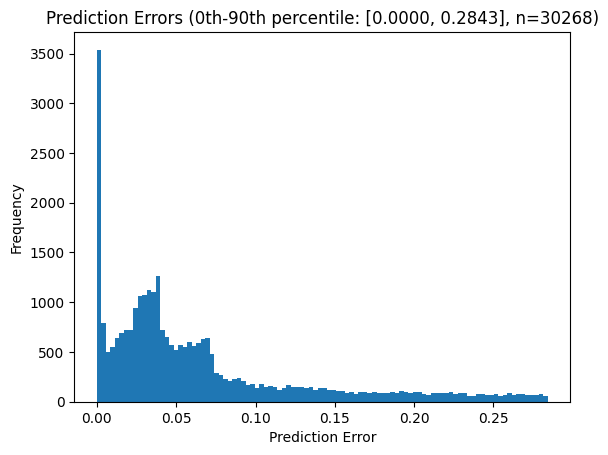

In [101]:
# Filter out first X percentile and last X percentile
lower_percentile = 0  # Remove bottom 10%
upper_percentile = 90  # Remove top 10%

lower_bound = np.percentile(predictions_errors_swingup, lower_percentile)
upper_bound = np.percentile(predictions_errors_swingup, upper_percentile)
filtered_errors = predictions_errors_swingup[
    (predictions_errors_swingup >= lower_bound) &
    (predictions_errors_swingup <= upper_bound)]

plt.hist(filtered_errors, bins=100)
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title(
    f'Prediction Errors ({lower_percentile}th-{upper_percentile}th percentile: [{lower_bound:.4f}, {upper_bound:.4f}], n={len(filtered_errors)})'
)
plt.show()

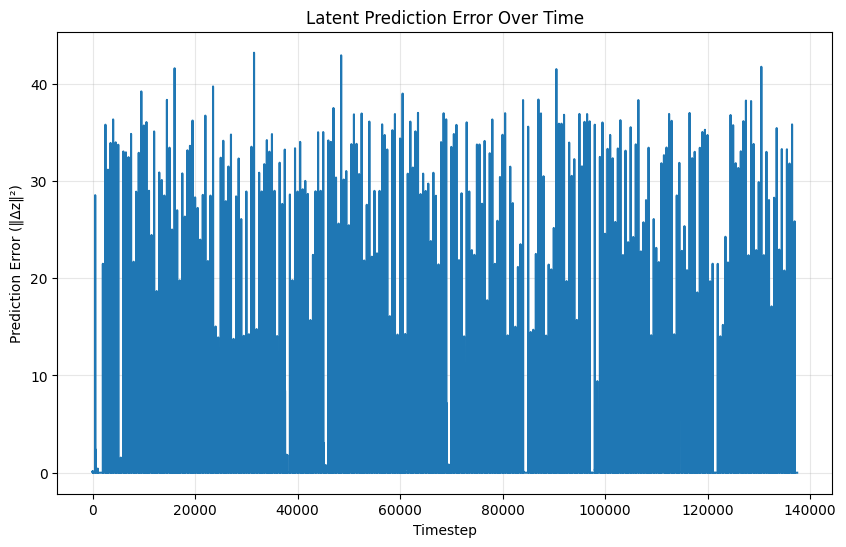

Mean prediction error: 0.0856
Std prediction error: 1.3287
Max prediction error: 43.1738
Min prediction error: 0.0000


In [59]:
# Plot prediction errors
plt.figure(figsize=(10, 6))
plt.plot(prediction_errors)
plt.xlabel('Timestep')
plt.ylabel('Prediction Error (‖Δz‖²)')
plt.title('Latent Prediction Error Over Time')
plt.grid(True, alpha=0.3)
plt.show()

# Summary statistics
print(f"Mean prediction error: {prediction_errors.mean():.4f}")
print(f"Std prediction error: {prediction_errors.std():.4f}")
print(f"Max prediction error: {prediction_errors.max():.4f}")
print(f"Min prediction error: {prediction_errors.min():.4f}")

## Prediction of one episode


In [45]:
episode = 8
idx_start = episode * 500
idx_end = (episode + 1) * 500
z_episode = z[idx_start:idx_end]
actions_episode = actions[idx_start:idx_end]
observations_episode = observations[idx_start:idx_end]


In [54]:
observations_episode

tensor([[ 0.0000,  0.3090,  0.9511, -0.0053, -0.0107],
        [-0.0018,  0.3059,  0.9521, -0.1734,  0.3356],
        [-0.0069,  0.2962,  0.9551, -0.3408,  0.6806],
        ...,
        [ 0.1924,  1.0000,  0.0010, -0.1182,  0.0213],
        [ 0.1900,  1.0000,  0.0015, -0.1197,  0.0238],
        [ 0.1876,  1.0000,  0.0019, -0.1168,  0.0201]], device='cuda:0')

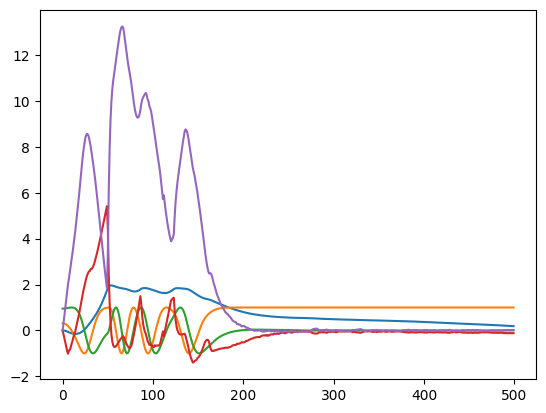

In [49]:
plt.plot(observations_episode.detach().cpu().numpy()[:])
plt.show()

In [ ]:
k = 500 - 1
prediction_errors_episode_open_loop, z_preds_episode_open_loop = compute_multistep_prediction_errors(
    agent,
    z_episode,
    actions_episode,
    observations_episode,
    k=k,
    open_loop=True)

prediction_errors_episode_closed_loop, z_preds_episode_closed_loop = compute_multistep_prediction_errors(
    agent,
    z_episode,
    actions_episode,
    observations_episode,
    k=k,
    open_loop=False)

prediction_errors_episode_open_loop_random_actions, z_preds_episode_open_loop_random_actions = compute_multistep_prediction_errors(
    agent,
    z_episode,
    actions_episode,
    observations_episode,
    k=k,
    open_loop=True,
    randomize_actions=True)

prediction_errors_episode_closed_loop_random_actions, z_preds_episode_closed_loop_random_actions = compute_multistep_prediction_errors(
    agent,
    z_episode,
    actions_episode,
    observations_episode,
    k=k,
    open_loop=False,
    randomize_actions=True)

# prediction_errors_episode_open_loop_linear_model, z_preds_episode_open_loop_linear_model = compute_multistep_prediction_errors(
#     agent,
#     z_episode,
#     actions_episode,
#     observations_episode,
#     k=k,
#     open_loop=True,
#     use_linear_model=True,
#     A=torch.from_numpy(A).to(z_episode.device),
#     B=torch.from_numpy(B).to(z_episode.device))

# prediction_errors_episode_closed_loop_linear_model, z_preds_episode_closed_loop_linear_model = compute_multistep_prediction_errors(
#     agent,
#     z_episode,
#     actions_episode,
#     observations_episode,
#     k=k,
#     open_loop=False,
#     use_linear_model=True,
#     A=torch.from_numpy(A).to(z_episode.device),
#     B=torch.from_numpy(B).to(z_episode.device))

prediction_errors_episode_closed_loop_zero_dynamics, z_preds_episode_closed_loop_zero_dynamics = compute_multistep_prediction_errors(
    agent,
    z_episode,
    actions_episode,
    observations_episode,
    k=k,
    open_loop=False,
    use_zero_dynamics=True)

prediction_errors_episode_open_loop_zero_dynamics, z_preds_episode_open_loop_zero_dynamics = compute_multistep_prediction_errors(
    agent,
    z_episode,
    actions_episode,
    observations_episode,
    k=k,
    open_loop=True,
    use_zero_dynamics=True)

100%|██████████| 1/1 [00:00<00:00,  9.38it/s]


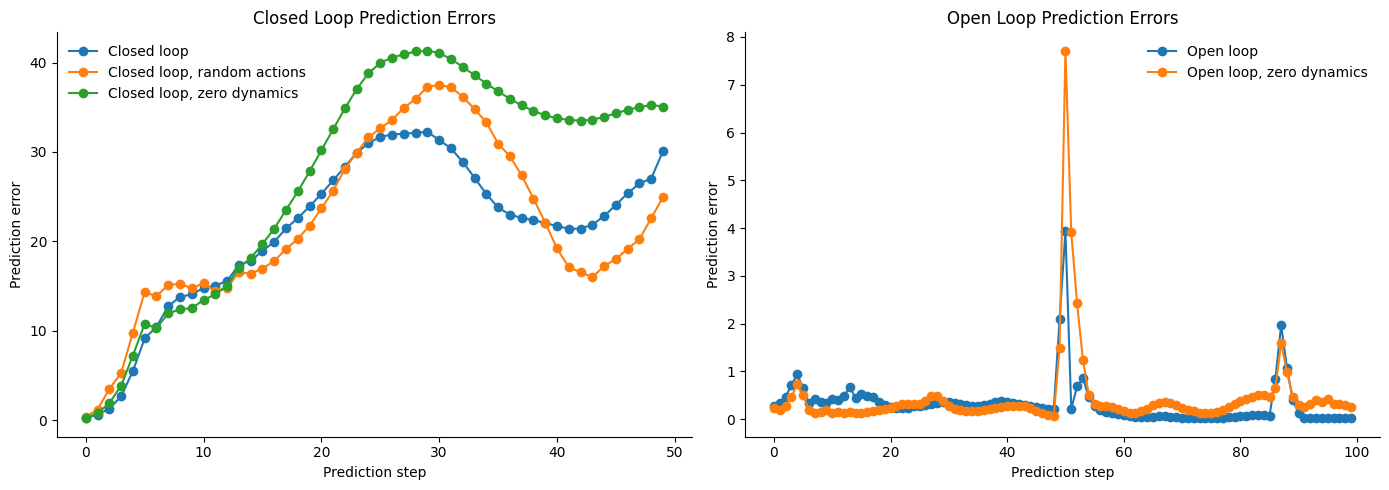

In [35]:
steps_to_plot = 50
steps_to_plot_open_loop = 100
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Closed loop plot (left)
ax1.plot(prediction_errors_episode_closed_loop[0, :steps_to_plot],
         marker='o',
         label='Closed loop')
ax1.plot(
    prediction_errors_episode_closed_loop_random_actions[0, :steps_to_plot],
    marker='o',
    label='Closed loop, random actions')
ax1.plot(prediction_errors_episode_closed_loop_zero_dynamics[0, :steps_to_plot],
         marker='o',
         label='Closed loop, zero dynamics')
ax1.set_xlabel('Prediction step')
ax1.set_ylabel('Prediction error')
ax1.set_title('Closed Loop Prediction Errors')
ax1.legend(frameon=False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Open loop plot (right)
ax2.plot(prediction_errors_episode_open_loop[0, :steps_to_plot_open_loop],
         marker='o',
         label='Open loop')
# ax2.plot(prediction_errors_episode_open_loop_random_actions[
#     0, :steps_to_plot_open_loop],
#          marker='o',
#          label='Open loop, random actions')
ax2.plot(prediction_errors_episode_open_loop_zero_dynamics[
    0, :steps_to_plot_open_loop],
         marker='o',
         label='Open loop, zero dynamics')
ax2.set_xlabel('Prediction step')
ax2.set_ylabel('Prediction error')
ax2.set_title('Open Loop Prediction Errors')
ax2.legend(frameon=False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()


In [44]:
steps_to_plot = 250
(prediction_errors_episode_open_loop[0, :steps_to_plot]
 < prediction_errors_episode_open_loop_zero_dynamics[0, :steps_to_plot]).mean()

0.74

In [40]:
prediction_errors_episode_open_loop.shape

(1, 499)

In [131]:
# Collect data from multiple episodes
num_episodes = 55
all_cart_positions = []
all_cos_pole_angles = []
all_sin_pole_angles = []
all_cart_velocities = []
all_pole_velocities = []
all_rewards = []
all_actions = []
all_prediction_errors = []
all_prediction_physical_errors = []

k = 500 - 1
for episode in range(num_episodes):
    idx_start = episode * 500
    idx_end = (episode + 1) * 500
    z_episode = z[idx_start:idx_end]
    actions_episode = actions[idx_start:idx_end]
    observations_episode = observations[idx_start:idx_end]
    rewards_episode = rewards[idx_start:idx_end]
    prediction_errors_episode_open_loop, prediction_physical_errors_episode_open_loop, _ = compute_multistep_prediction_errors(
        agent,
        z_episode,
        actions_episode,
        observations_episode,
        k=k,
        open_loop=True,
        add_physical_error=True,
        decoder=decoder)

    # Collect data for plotting
    all_cart_positions.append(observations_episode.detach().cpu().numpy()[:-1,
                                                                          0])
    all_cos_pole_angles.append(observations_episode.detach().cpu().numpy()[:-1,
                                                                           1])
    all_sin_pole_angles.append(observations_episode.detach().cpu().numpy()[:-1,
                                                                           2])
    all_cart_velocities.append(observations_episode.detach().cpu().numpy()[:-1,
                                                                           3])
    all_pole_velocities.append(observations_episode.detach().cpu().numpy()[:-1,
                                                                           4])
    all_actions.append(actions_episode.detach().cpu().numpy()[:-1, :])
    all_prediction_errors.append(prediction_errors_episode_open_loop[0, :])
    all_prediction_physical_errors.append(
        prediction_physical_errors_episode_open_loop[0, :])
    all_rewards.append(rewards_episode[:-1])
# Concatenate all episodes
all_cart_positions = np.concatenate(all_cart_positions)
all_cos_pole_angles = np.concatenate(all_cos_pole_angles)
all_sin_pole_angles = np.concatenate(all_sin_pole_angles)
all_cart_velocities = np.concatenate(all_cart_velocities)
all_pole_velocities = np.concatenate(all_pole_velocities)
all_actions = np.concatenate(all_actions)
all_prediction_errors = np.concatenate(all_prediction_errors)
all_prediction_physical_errors = np.concatenate(all_prediction_physical_errors)
all_rewards = np.concatenate(all_rewards)

100%|██████████| 1/1 [00:00<00:00,  3.33it/s]


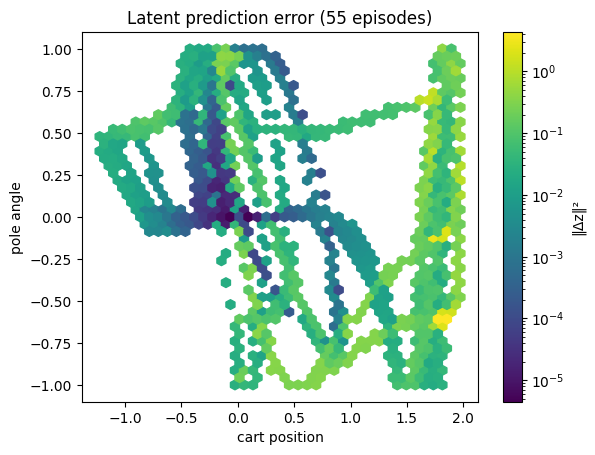

In [74]:
# Plot all episodes together
plt.hexbin(all_cart_positions,
           all_sin_pole_angles,
           C=all_prediction_errors,
           gridsize=40,
           cmap='viridis',
           bins='log')
#vmax=.5)
plt.xlabel('cart position')
plt.ylabel('pole angle')
plt.title(f'Latent prediction error ({num_episodes} episodes)')
plt.colorbar(label='‖Δz‖²')

## Where does the model predict well?

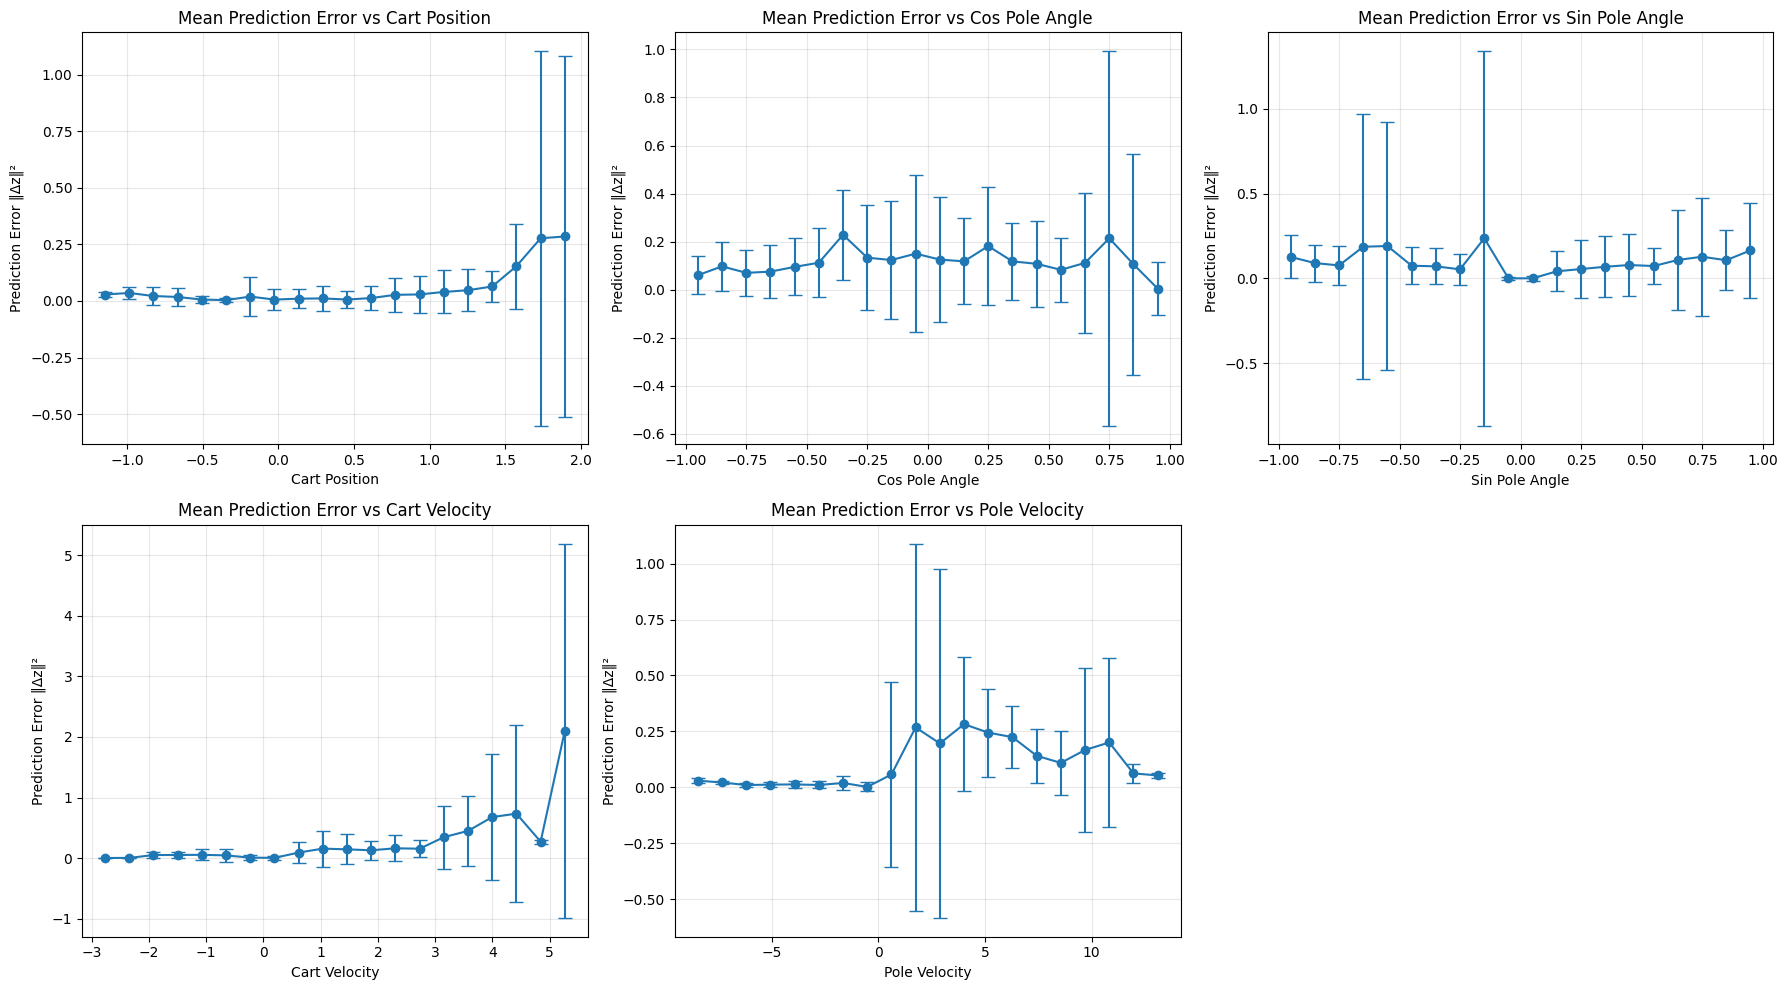

In [80]:
# Create figure with 2 rows and 3 columns
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# List of variables to analyze
variables = [(all_cart_positions, 'Cart Position'),
             (all_cos_pole_angles, 'Cos Pole Angle'),
             (all_sin_pole_angles, 'Sin Pole Angle'),
             (all_cart_velocities, 'Cart Velocity'),
             (all_pole_velocities, 'Pole Velocity')]

num_bins = 20

for idx, (variable_data, variable_name) in enumerate(variables):
    ax = axes[idx]

    # Divide variable into bins and compute statistics
    bin_edges = np.linspace(variable_data.min(), variable_data.max(),
                            num_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Compute mean and std prediction error per bin
    mean_errors = []
    std_errors = []

    for i in range(num_bins):
        mask = (variable_data >= bin_edges[i]) & (variable_data
                                                  < bin_edges[i + 1])
        errors_in_bin = all_prediction_errors[mask]

        if len(errors_in_bin) > 0:
            mean_errors.append(np.mean(errors_in_bin))
            std_errors.append(np.std(errors_in_bin))
        else:
            mean_errors.append(np.nan)
            std_errors.append(np.nan)

    mean_errors = np.array(mean_errors)
    std_errors = np.array(std_errors)

    # Plot mean and std prediction error per bin
    ax.errorbar(bin_centers, mean_errors, yerr=std_errors, fmt='o-', capsize=5)
    ax.set_xlabel(variable_name)
    ax.set_ylabel('Prediction Error ‖Δz‖²')
    ax.set_title(f'Mean Prediction Error vs {variable_name}')
    ax.grid(True, alpha=0.3)
    #ax.set_ylim(-1, 1.5)

# Remove the 6th subplot (empty)
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

## does high latent error correlate with low reward or failure?

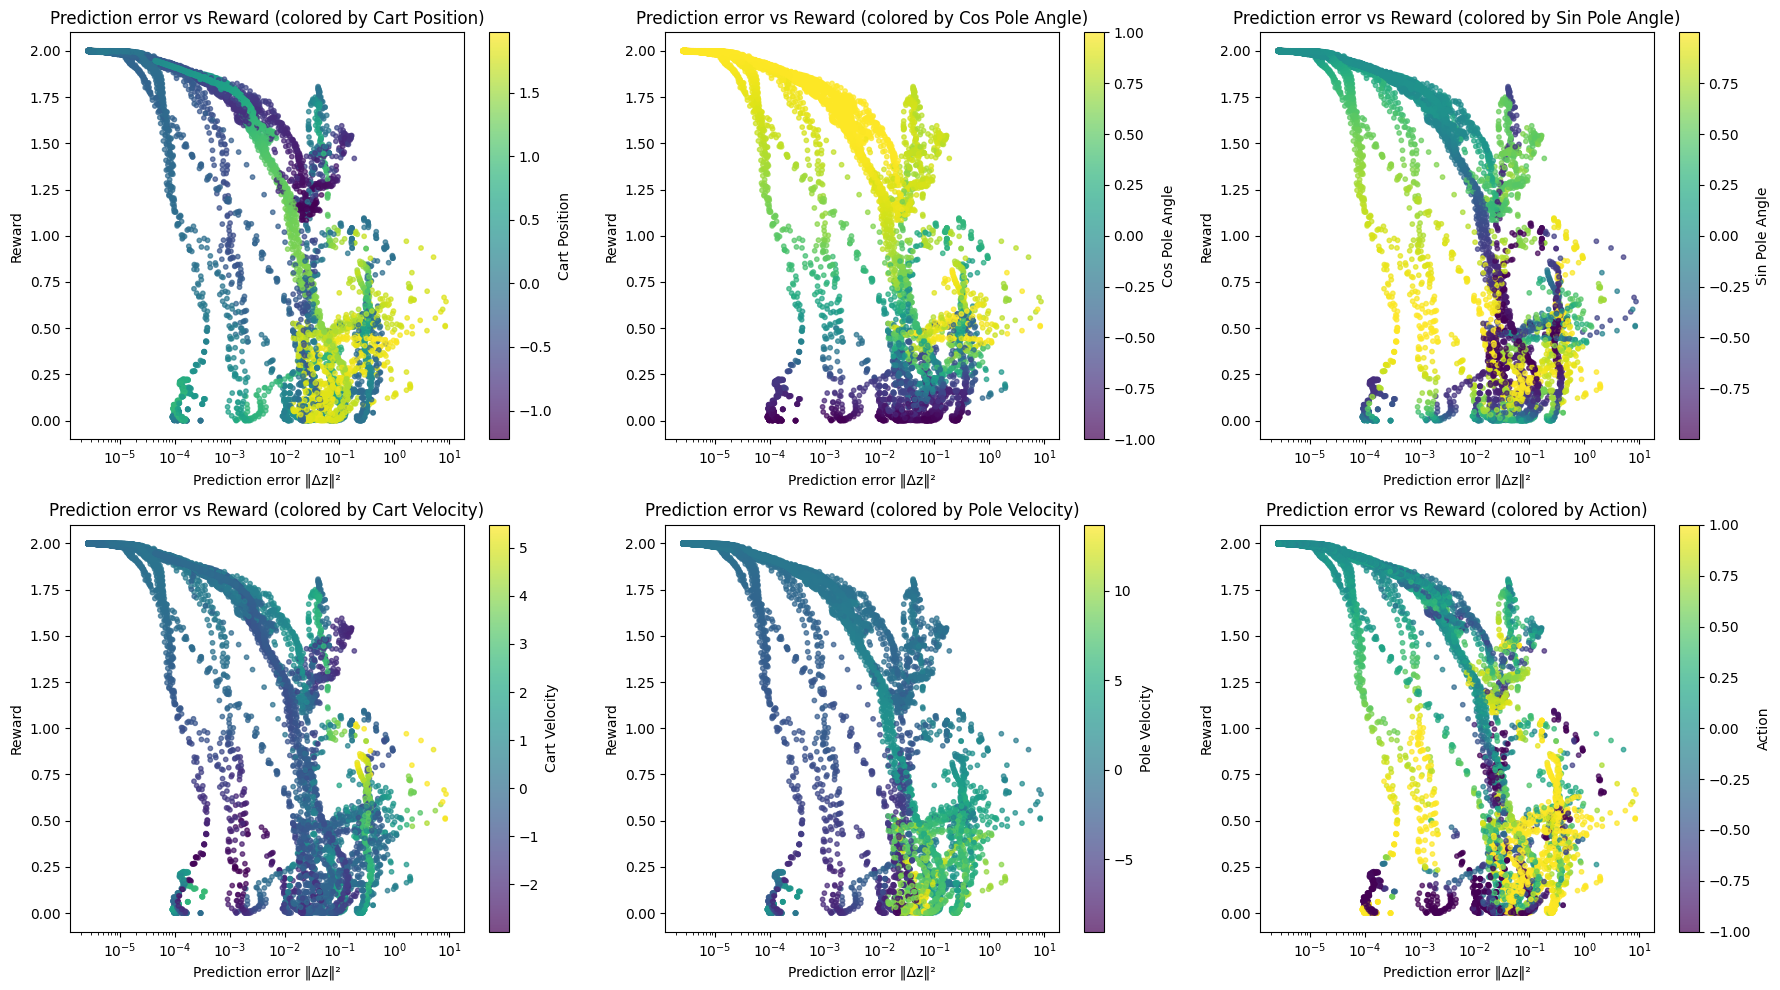

In [136]:
# Create subplots: 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# List of variables to analyze
variables = [(all_cart_positions, 'Cart Position'),
             (all_cos_pole_angles, 'Cos Pole Angle'),
             (all_sin_pole_angles, 'Sin Pole Angle'),
             (all_cart_velocities, 'Cart Velocity'),
             (all_pole_velocities, 'Pole Velocity'), (all_actions, 'Action')]

for idx, (variable_data, variable_name) in enumerate(variables):
    ax = axes[idx]

    scatter = ax.scatter(all_prediction_errors,
                         all_rewards,
                         c=variable_data,
                         alpha=0.7,
                         s=10,
                         cmap='viridis')
    ax.set_xlabel('Prediction error ‖Δz‖²')
    ax.set_ylabel('Reward')
    ax.set_title(f'Prediction error vs Reward (colored by {variable_name})')
    plt.colorbar(scatter, ax=ax, label=variable_name)
    ax.set_xscale('log')

# Remove the 6th subplot (empty)
#fig.delaxes(axes[5])

plt.tight_layout()
plt.show()


## Latent vs physical prediction errors

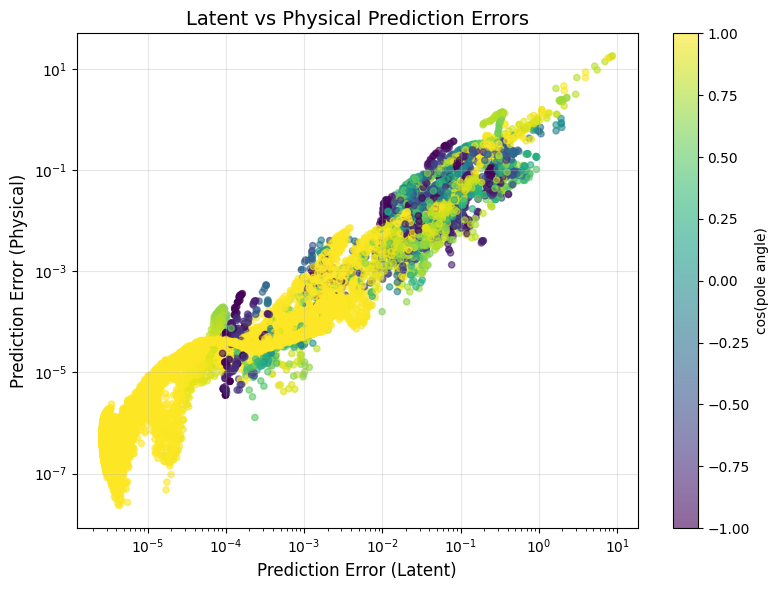

In [137]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(all_prediction_errors,
                     all_prediction_physical_errors,
                     c=all_cos_pole_angles,
                     alpha=0.6,
                     s=20,
                     cmap='viridis')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Prediction Error (Latent)', fontsize=12)
ax.set_ylabel('Prediction Error (Physical)', fontsize=12)
ax.set_title('Latent vs Physical Prediction Errors', fontsize=14)
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='cos(pole angle)')
plt.tight_layout()
plt.show()